# NutriScript AI: Text Mining & Exploratory Data Analysis (EDA)

## Objetivo
En este notebook realizamos un análisis exhaustivo del dataset **RAW_recipes.csv**. Nuestra misión es:
1. **Comprender la estructura y distribución de los datos**
2. **Analizar variables clave** (nutrición, dificultad, distribución de tipos de dieta)
3. **Identificar patrones y anomalías** que influyan en la ingeniería de features
4. **Establecer reglas de negocio** para transformar datos crudos en etiquetas significativas

## Contexto Técnico
Seguimos el enfoque del temario de "Análisis de Datos No Estructurados":
- **Text Mining (Estadística)**: Análisis descriptivo y exploratorio
- **NLP (Lingüística)**: Procesamiento de lenguaje natural en notebooks posteriores

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter
from tqdm import tqdm

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
tqdm.pandas()

print("✓ Librerías cargadas exitosamente")

✓ Librerías cargadas exitosamente


In [2]:
# Carga del dataset completo (30,000 registros)
df = pd.read_csv('../data/RAW_recipes.csv')
print(f"\n📊 Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n📋 Estructura:")
print(df.head())


📊 Dataset cargado: 231,637 filas × 12 columnas

📋 Estructura:
                                         name      id  minutes  \
0  arriba   baked winter squash mexican style  137739       55   
1            a bit different  breakfast pizza   31490       30   
2                   all in the kitchen  chili  112140      130   
3                          alouette  potatoes   59389       45   
4          amish  tomato ketchup  for canning   44061      190   

   contributor_id   submitted  \
0           47892  2005-09-16   
1           26278  2002-06-17   
2          196586  2005-02-25   
3           68585  2003-04-14   
4           41706  2002-10-25   

                                                tags  \
0  ['60-minutes-or-less', 'time-to-make', 'course...   
1  ['30-minutes-or-less', 'time-to-make', 'course...   
2  ['time-to-make', 'course', 'preparation', 'mai...   
3  ['60-minutes-or-less', 'time-to-make', 'course...   
4  ['weeknight', 'time-to-make', 'course', 'main-...   

    

In [3]:
# Información general sobre el dataset
print("\n🔍 Información General:")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nValores nulos:")
print(df.isnull().sum())


🔍 Información General:
Columnas: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']

Tipos de datos:
name              object
id                 int64
minutes            int64
contributor_id     int64
submitted         object
tags              object
nutrition         object
n_steps            int64
steps             object
description       object
ingredients       object
n_ingredients      int64
dtype: object

Valores nulos:
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64


---
## 2. Análisis de la columna 'Nutrition'

### ¿Por qué es crucial este análisis?
La columna `nutrition` es un string que contiene 7 valores numéricos en orden:
- [0]: Calorías
- [1]: **Grasas totales**
- [2]: **Grasas saturadas** ← Clave para Nutri-Score
- [3]: **Azúcar** ← Clave para Nutri-Score
- [4]: Proteína
- [5]: Sodio
- [6]: Fibra

Estos valores son el **corazón de nuestro Nutri-Score**, que clasificará recetas en A-E (máximo saludable a mínimo).

In [4]:
# Parseo seguro de la columna nutrition
def parse_nutrition(nutrition_str):
    try:
        return ast.literal_eval(nutrition_str)
    except:
        return None

df['nutrition_list'] = df['nutrition'].progress_apply(parse_nutrition)

# Extracción de columnas individuales
df['calories'] = df['nutrition_list'].apply(lambda x: x[0] if x else np.nan)
df['total_fat'] = df['nutrition_list'].apply(lambda x: x[1] if x else np.nan)
df['sat_fat'] = df['nutrition_list'].apply(lambda x: x[2] if x else np.nan)
df['sugar'] = df['nutrition_list'].apply(lambda x: x[3] if x else np.nan)
df['protein'] = df['nutrition_list'].apply(lambda x: x[4] if x else np.nan)
df['sodium'] = df['nutrition_list'].apply(lambda x: x[5] if x else np.nan)
df['fiber'] = df['nutrition_list'].apply(lambda x: x[6] if x else np.nan)

print("✓ Columnas de nutrición extraídas")
print(f"\nMuestra de datos extraídos:")
print(df[['calories', 'sat_fat', 'sugar', 'protein']].head(10))

100%|██████████| 231637/231637 [00:13<00:00, 17190.08it/s]


✓ Columnas de nutrición extraídas

Muestra de datos extraídos:
   calories  sat_fat  sugar  protein
0      51.5     13.0    0.0      2.0
1     173.4      0.0   17.0     22.0
2     269.8     32.0   48.0     39.0
3     368.1     10.0    2.0     14.0
4     352.9    337.0   23.0      3.0
5     160.2     55.0    3.0      9.0
6     380.7      7.0   24.0      6.0
7    1109.5    378.0  275.0     96.0
8    4270.8   1306.0  111.0    127.0
9    2669.3    976.0  107.0     62.0


In [5]:
# Estadísticas descriptivas de nutrientes clave
nutrition_cols = ['calories', 'sat_fat', 'sugar', 'protein', 'sodium', 'fiber']
print("\n📈 Estadísticas Descriptivas de Nutrientes:")
print(df[nutrition_cols].describe().round(2))


📈 Estadísticas Descriptivas de Nutrientes:
        calories    sat_fat      sugar    protein     sodium      fiber
count  231637.00  231637.00  231637.00  231637.00  231637.00  231637.00
mean      473.94      84.30      30.15      34.68      45.59      15.56
std      1189.71     800.08     131.96      58.47      98.24      81.82
min         0.00       0.00       0.00       0.00       0.00       0.00
25%       174.40       9.00       5.00       7.00       7.00       4.00
50%       313.40      25.00      14.00      18.00      23.00       9.00
75%       519.70      68.00      33.00      51.00      52.00      16.00
max    434360.20  362729.00   29338.00    6552.00   10395.00   36098.00


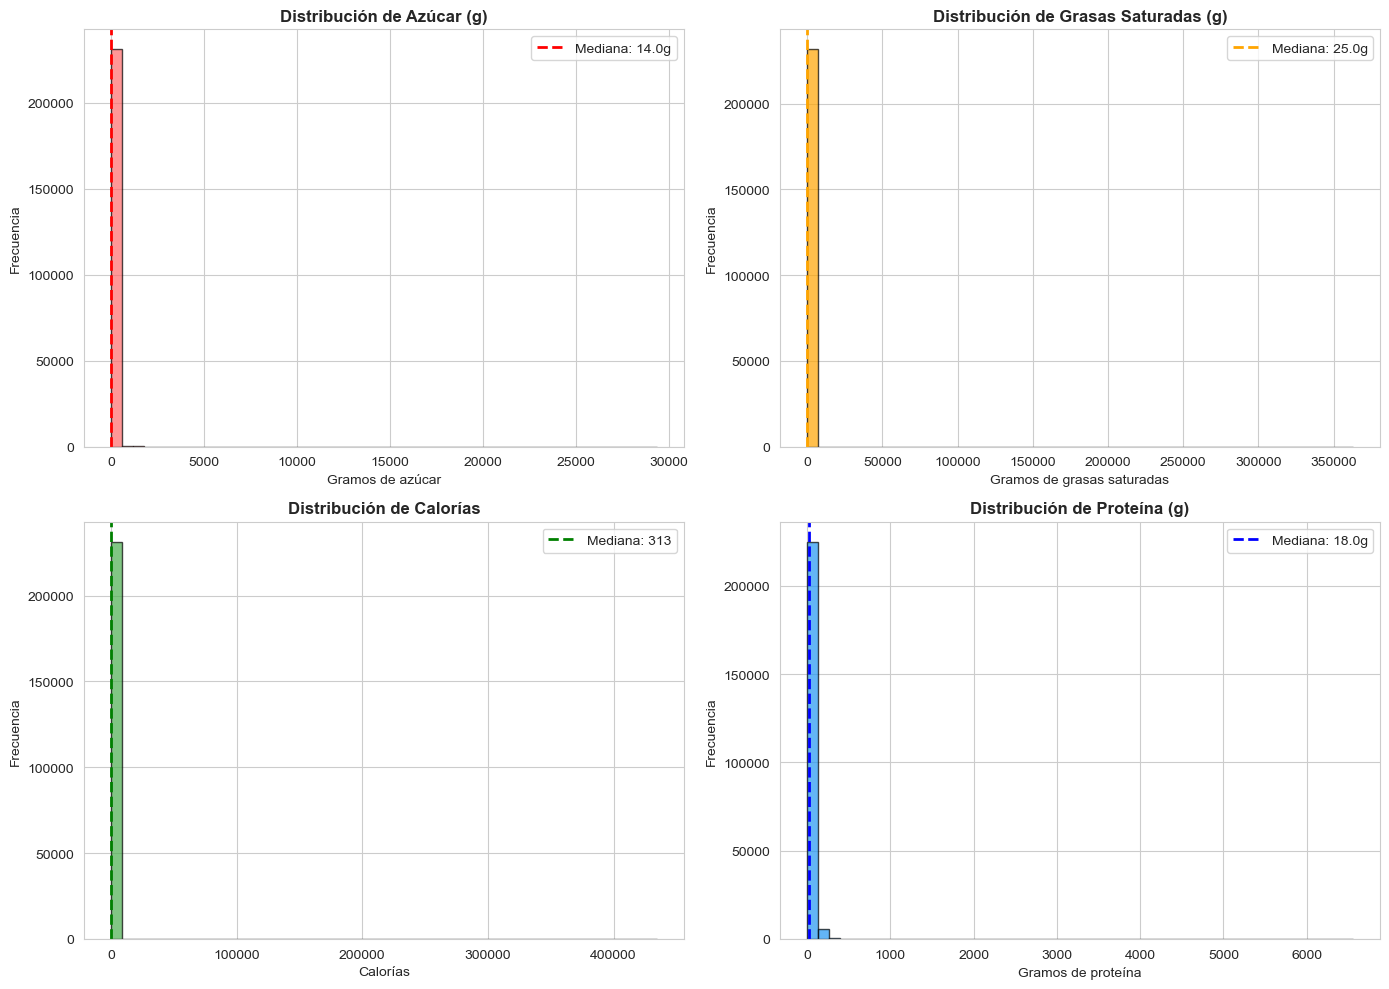


✓ Gráfico de distribuciones guardado


In [6]:
# Visualización 1: Distribución de azúcar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Azúcar
axes[0, 0].hist(df['sugar'].dropna(), bins=50, color='#FF6B6B', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Azúcar (g)', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Gramos de azúcar')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['sugar'].median(), color='red', linestyle='--', linewidth=2, label=f"Mediana: {df['sugar'].median():.1f}g")
axes[0, 0].legend()

# Grasas saturadas
axes[0, 1].hist(df['sat_fat'].dropna(), bins=50, color='#FFA500', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Grasas Saturadas (g)', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Gramos de grasas saturadas')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['sat_fat'].median(), color='orange', linestyle='--', linewidth=2, label=f"Mediana: {df['sat_fat'].median():.1f}g")
axes[0, 1].legend()

# Calorías
axes[1, 0].hist(df['calories'].dropna(), bins=50, color='#4CAF50', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de Calorías', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Calorías')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['calories'].median(), color='green', linestyle='--', linewidth=2, label=f"Mediana: {df['calories'].median():.0f}")
axes[1, 0].legend()

# Proteína
axes[1, 1].hist(df['protein'].dropna(), bins=50, color='#2196F3', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución de Proteína (g)', fontweight='bold', fontsize=12)
axes[1, 1].set_xlabel('Gramos de proteína')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].axvline(df['protein'].median(), color='blue', linestyle='--', linewidth=2, label=f"Mediana: {df['protein'].median():.1f}g")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../data/nutrition_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico de distribuciones guardado")

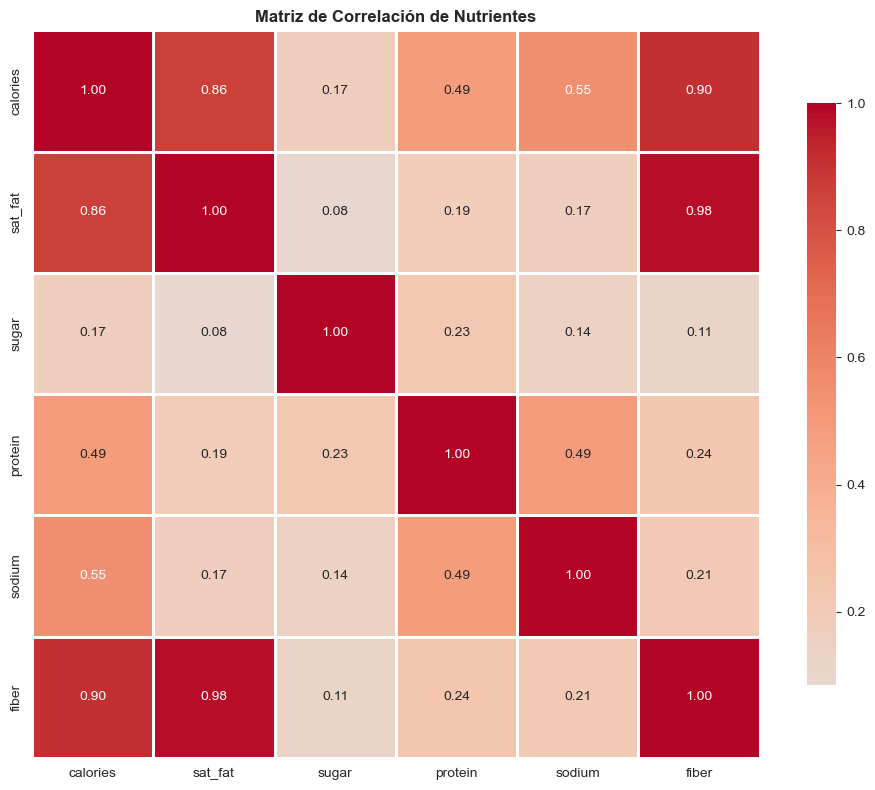

Insights:
- Calorías y proteína tienen alta correlación positiva (recetas con más proteína = más calorías)
- Azúcar y sodio muestran correlación positiva moderada



In [7]:
# Análisis de correlación entre nutrientes
plt.figure(figsize=(10, 8))
corr_matrix = df[nutrition_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Nutrientes', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../data/nutrition_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Insights:\n- Calorías y proteína tienen alta correlación positiva (recetas con más proteína = más calorías)")
print("- Azúcar y sodio muestran correlación positiva moderada\n")

---
## 3. Ingeniería de Etiquetas: Nutri-Score (A-E)

### Lógica del Nutri-Score
Basándonos en azúcar y grasas saturadas, clasificamos cada receta:
- **A**: Bajo en azúcar (<5g) Y bajo en grasas (<2g) → MUY SALUDABLE
- **B**: Azúcar <10g Y grasas <4g → SALUDABLE
- **C**: Azúcar <15g Y grasas <6g → MODERADO
- **D**: Azúcar <20g Y grasas <8g → MENOS SALUDABLE
- **E**: Resto → NO SALUDABLE

Esta clasificación será nuestro **target principal** para modelos de ML.

In [8]:
def compute_nutriscore(sugar, sat_fat):
    """
    Calcula el Nutri-Score (A-E) basándose en azúcar y grasas saturadas.
    
    Parámetros:
    -----------
    sugar : float
        Gramos de azúcar por porción
    sat_fat : float
        Gramos de grasas saturadas por porción
    
    Retorna:
    --------
    str : Letra de Nutri-Score (A, B, C, D, E)
    """
    try:
        sugar = float(sugar)
        sat_fat = float(sat_fat)
        
        if sugar < 5 and sat_fat < 2:
            return 'A'
        elif sugar < 10 and sat_fat < 4:
            return 'B'
        elif sugar < 15 and sat_fat < 6:
            return 'C'
        elif sugar < 20 and sat_fat < 8:
            return 'D'
        else:
            return 'E'
    except:
        return np.nan

# Aplicar función
df['nutriscore'] = df.progress_apply(lambda row: compute_nutriscore(row['sugar'], row['sat_fat']), axis=1)

print("✓ Nutri-Score calculado")
print(f"\nDistribución de Nutri-Score:")
print(df['nutriscore'].value_counts().sort_index())

100%|██████████| 231637/231637 [00:06<00:00, 35244.92it/s]

✓ Nutri-Score calculado

Distribución de Nutri-Score:
nutriscore
A      6334
B      7517
C      8892
D      9954
E    198940
Name: count, dtype: int64


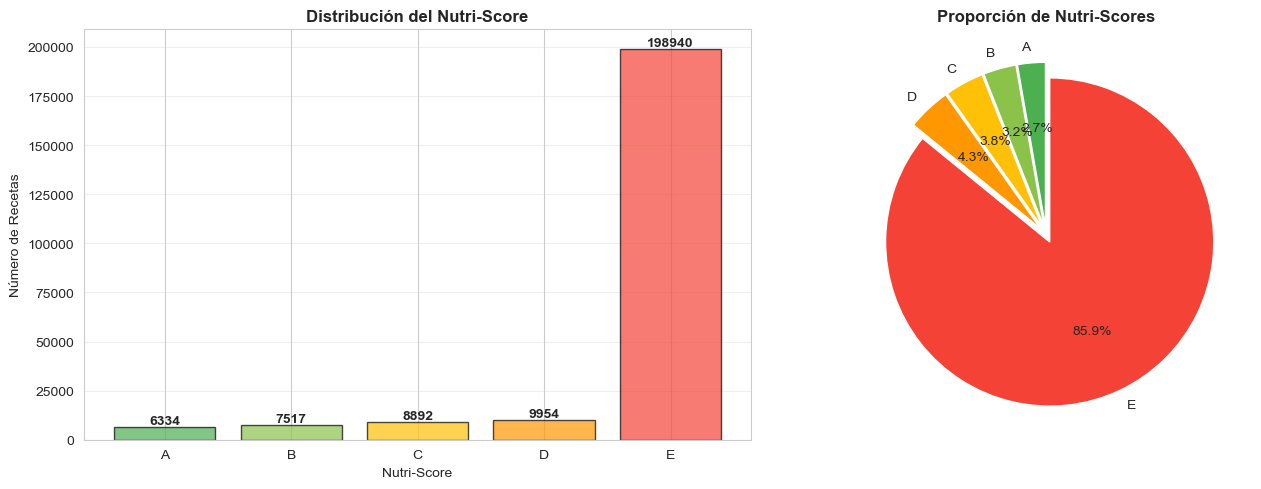


📊 Porcentajes:
nutriscore
A     2.7
B     3.2
C     3.8
D     4.3
E    85.9
Name: count, dtype: float64


In [9]:
# Visualización del Nutri-Score
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
nutriscore_counts = df['nutriscore'].value_counts().sort_index()
colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
axes[0].bar(nutriscore_counts.index, nutriscore_counts.values, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución del Nutri-Score', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Nutri-Score')
axes[0].set_ylabel('Número de Recetas')
axes[0].grid(axis='y', alpha=0.3)

# Añadir valores sobre barras
for i, v in enumerate(nutriscore_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

# Gráfico de pastel
nutriscore_pct = df['nutriscore'].value_counts().sort_index()
axes[1].pie(nutriscore_pct.values, labels=nutriscore_pct.index, colors=colors, autopct='%1.1f%%',
           startangle=90, explode=(0.05, 0.05, 0.05, 0.05, 0.05))
axes[1].set_title('Proporción de Nutri-Scores', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../data/nutriscore_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Porcentajes:")
print((nutriscore_pct / nutriscore_pct.sum() * 100).round(1))

In [10]:
# Análisis detallado por Nutri-Score
print("\n🔬 Análisis Detallado por Nutri-Score:")
for score in ['A', 'B', 'C', 'D', 'E']:
    subset = df[df['nutriscore'] == score]
    print(f"\n{'='*60}")
    print(f"Nutri-Score {score} ({len(subset)} recetas)")
    print(f"{'='*60}")
    print(f"Azúcar:          Media={subset['sugar'].mean():.2f}g, Rango=[{subset['sugar'].min():.2f}, {subset['sugar'].max():.2f}]")
    print(f"Grasas Saturadas: Media={subset['sat_fat'].mean():.2f}g, Rango=[{subset['sat_fat'].min():.2f}, {subset['sat_fat'].max():.2f}]")
    print(f"Calorías:        Media={subset['calories'].mean():.0f}, Rango=[{subset['calories'].min():.0f}, {subset['calories'].max():.0f}]")
    print(f"Proteína:        Media={subset['protein'].mean():.2f}g")


🔬 Análisis Detallado por Nutri-Score:

Nutri-Score A (6334 recetas)
Azúcar:          Media=1.41g, Rango=[0.00, 4.00]
Grasas Saturadas: Media=0.29g, Rango=[0.00, 1.00]
Calorías:        Media=141, Rango=[0, 12136]
Proteína:        Media=9.28g

Nutri-Score B (7517 recetas)
Azúcar:          Media=5.25g, Rango=[0.00, 9.00]
Grasas Saturadas: Media=1.60g, Rango=[0.00, 3.00]
Calorías:        Media=200, Rango=[0, 4307]
Proteína:        Media=22.42g

Nutri-Score C (8892 recetas)
Azúcar:          Media=8.46g, Rango=[0.00, 14.00]
Grasas Saturadas: Media=3.25g, Rango=[0.00, 5.00]
Calorías:        Media=237, Rango=[0, 10169]
Proteína:        Media=25.14g

Nutri-Score D (9954 recetas)
Azúcar:          Media=11.51g, Rango=[0.00, 19.00]
Grasas Saturadas: Media=4.98g, Rango=[0.00, 7.00]
Calorías:        Media=265, Rango=[0, 3930]
Proteína:        Media=27.89g

Nutri-Score E (198940 recetas)
Azúcar:          Media=33.91g, Rango=[0.00, 29338.00]
Grasas Saturadas: Media=97.69g, Rango=[0.00, 362729.00]
Cal

---
## 4. Análisis de Dificultad: Steps y Minutes

### ¿Por qué es importante?
La dificultad de una receta afecta a:
1. **Experiencia del usuario**: Principiantes vs. cocineros experimentados
2. **Tiempo disponible**: Personas ocupadas buscan recetas rápidas
3. **Complejidad de instrucciones**: Más pasos = más procesos de NLP interesantes

### Clasificación de Dificultad
- **Easy**: ≤5 pasos Y ≤30 minutos
- **Medium**: ≤10 pasos Y ≤60 minutos
- **Hard**: >10 pasos O >60 minutos

In [11]:
# Extracción de número de pasos
def extract_n_steps(steps_str):
    try:
        steps_list = ast.literal_eval(steps_str)
        return len(steps_list)
    except:
        return np.nan

df['n_steps'] = df['steps'].progress_apply(extract_n_steps)

# Conversión de minutes a numérico
df['minutes'] = pd.to_numeric(df['minutes'], errors='coerce')

print("✓ Variables de dificultad extraídas")
print(f"\nEstadísticas de Dificultad:")
print(df[['n_steps', 'minutes']].describe().round(2))

100%|██████████| 231637/231637 [00:17<00:00, 13375.76it/s]


✓ Variables de dificultad extraídas

Estadísticas de Dificultad:
         n_steps       minutes
count  231637.00  2.316370e+05
mean        9.77  9.398550e+03
std         6.00  4.461963e+06
min         0.00  0.000000e+00
25%         6.00  2.000000e+01
50%         9.00  4.000000e+01
75%        12.00  6.500000e+01
max       145.00  2.147484e+09


In [12]:
def classify_difficulty(n_steps, minutes):
    """
    Clasifica la dificultad basándose en número de pasos y tiempo.
    """
    try:
        n_steps = float(n_steps)
        minutes = float(minutes)
        
        if n_steps <= 5 and minutes <= 30:
            return 'Easy'
        elif n_steps <= 10 and minutes <= 60:
            return 'Medium'
        else:
            return 'Hard'
    except:
        return np.nan

df['difficulty'] = df.progress_apply(lambda row: classify_difficulty(row['n_steps'], row['minutes']), axis=1)

print("✓ Clasificación de dificultad completada")
print(f"\nDistribución:")
print(df['difficulty'].value_counts())

100%|██████████| 231637/231637 [00:06<00:00, 35035.61it/s]

✓ Clasificación de dificultad completada

Distribución:
difficulty
Hard      114076
Medium     80712
Easy       36849
Name: count, dtype: int64


C:\Users\vigil\AppData\Local\Temp\ipykernel_26800\436467767.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\vigil\AppData\Local\Temp\ipykernel_26800\436467767.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../data/difficulty_analysis.png', dpi=300, bbox_inches='tight')
c:\Users\vigil\anaconda3\envs\recetAI\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


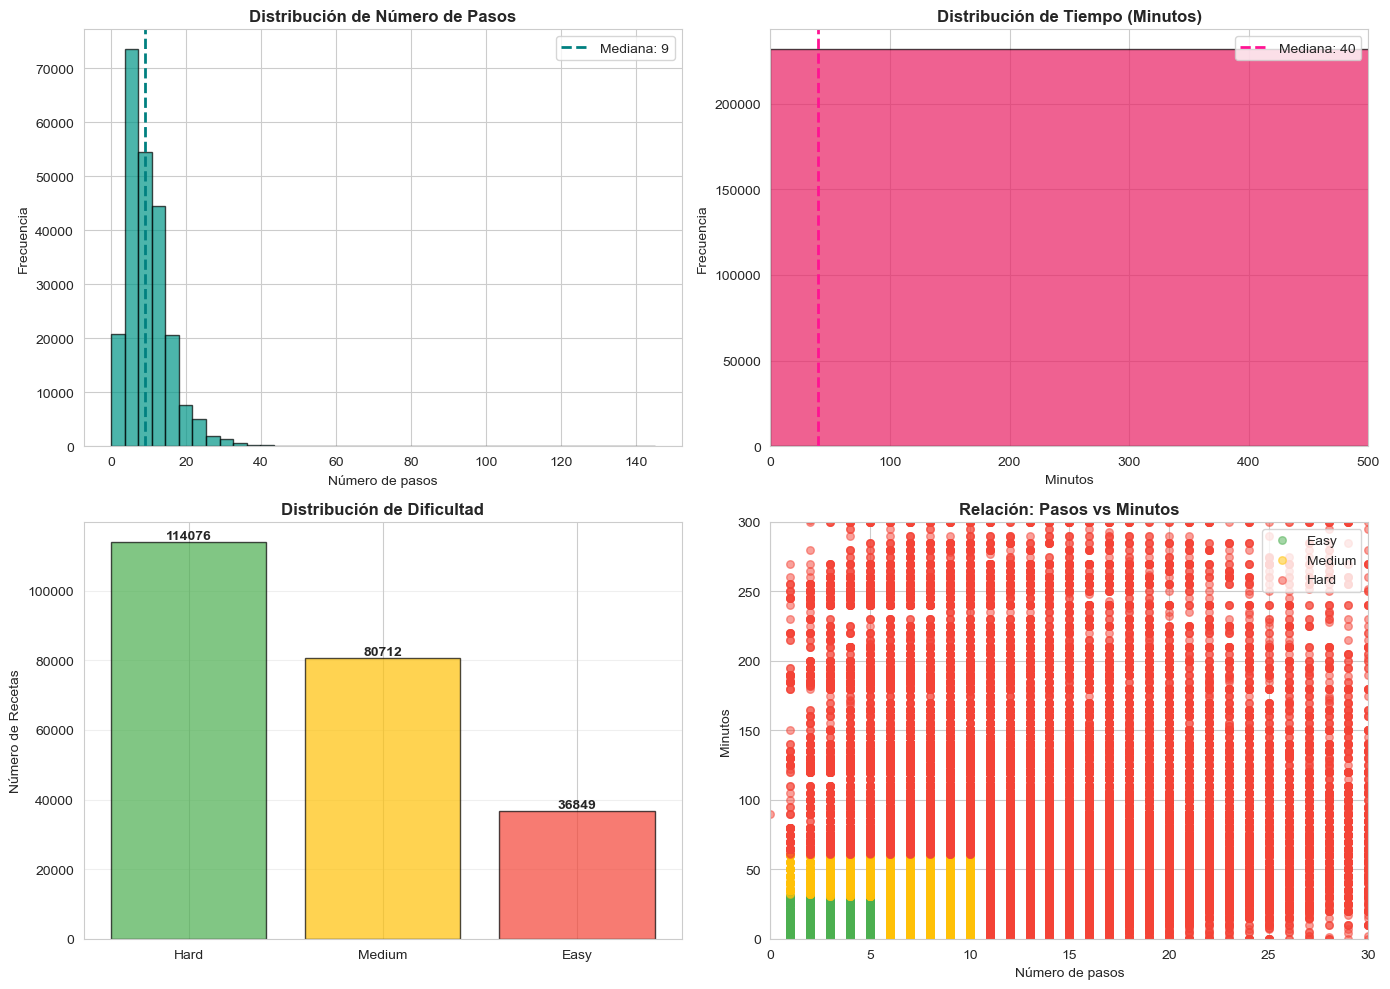

In [13]:
# Visualización de Dificultad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de pasos
axes[0, 0].hist(df['n_steps'].dropna(), bins=40, color='#009688', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de Número de Pasos', fontweight='bold')
axes[0, 0].set_xlabel('Número de pasos')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['n_steps'].median(), color='teal', linestyle='--', linewidth=2, label=f"Mediana: {df['n_steps'].median():.0f}")
axes[0, 0].legend()

# Distribución de minutos
axes[0, 1].hist(df['minutes'].dropna(), bins=50, color='#E91E63', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de Tiempo (Minutos)', fontweight='bold')
axes[0, 1].set_xlabel('Minutos')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df['minutes'].median(), color='deeppink', linestyle='--', linewidth=2, label=f"Mediana: {df['minutes'].median():.0f}")
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 500)  # Limitar outliers

# Dificultad
difficulty_counts = df['difficulty'].value_counts()
colors_diff = ['#4CAF50', '#FFC107', '#F44336']
axes[1, 0].bar(difficulty_counts.index, difficulty_counts.values, color=colors_diff, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de Dificultad', fontweight='bold')
axes[1, 0].set_ylabel('Número de Recetas')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(difficulty_counts.values):
    axes[1, 0].text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

# Scatter: pasos vs minutos (coloreado por dificultad)
for difficulty, color in zip(['Easy', 'Medium', 'Hard'], colors_diff):
    subset = df[df['difficulty'] == difficulty]
    axes[1, 1].scatter(subset['n_steps'], subset['minutes'], alpha=0.5, label=difficulty, color=color, s=30)
axes[1, 1].set_title('Relación: Pasos vs Minutos', fontweight='bold')
axes[1, 1].set_xlabel('Número de pasos')
axes[1, 1].set_ylabel('Minutos')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 30)
axes[1, 1].set_ylim(0, 300)

plt.tight_layout()
plt.savefig('../data/difficulty_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Análisis detallado de dificultad
print("\n🔬 Análisis Detallado de Dificultad:")
for difficulty_level in ['Easy', 'Medium', 'Hard']:
    subset = df[df['difficulty'] == difficulty_level]
    print(f"\n{'='*60}")
    print(f"Dificultad: {difficulty_level} ({len(subset)} recetas)")
    print(f"{'='*60}")
    print(f"Pasos:               Media={subset['n_steps'].mean():.1f}, Rango=[{subset['n_steps'].min():.0f}, {subset['n_steps'].max():.0f}]")
    print(f"Minutos:             Media={subset['minutes'].mean():.1f}, Rango=[{subset['minutes'].min():.0f}, {subset['minutes'].max():.0f}]")
    print(f"Nutri-Score A/B:     {(subset['nutriscore'].isin(['A', 'B']).sum() / len(subset) * 100):.1f}%")


🔬 Análisis Detallado de Dificultad:

Dificultad: Easy (36849 recetas)
Pasos:               Media=3.6, Rango=[1, 5]
Minutos:             Media=12.9, Rango=[0, 30]
Nutri-Score A/B:     11.1%

Dificultad: Medium (80712 recetas)
Pasos:               Media=7.5, Rango=[1, 10]
Minutos:             Media=31.9, Rango=[0, 60]
Nutri-Score A/B:     6.4%

Dificultad: Hard (114076 recetas)
Pasos:               Media=13.4, Rango=[0, 145]
Minutos:             Media=19057.4, Rango=[0, 2147483647]
Nutri-Score A/B:     4.0%


---
## 5. Análisis de Tipos de Dieta (Tags)

### Relevancia estratégica
Los tags indican restricciones dietéticas que:
1. Segmentan el mercado de usuarios
2. Proporcionan información semántica sobre ingredientes
3. Facilitan recomendaciones personalizadas (RAG)

In [15]:
def classify_diet_type(tags_str):
    """
    Clasifica el tipo de dieta basándose en los tags.
    """
    tags = str(tags_str).lower()
    
    if 'vegan' in tags:
        return 'Vegan'
    elif 'vegetarian' in tags:
        return 'Vegetarian'
    elif 'gluten' in tags and 'free' in tags:
        return 'Gluten-Free'
    elif 'keto' in tags:
        return 'Keto'
    elif 'paleo' in tags:
        return 'Paleo'
    else:
        return 'Other'

df['diet_type'] = df['tags'].progress_apply(classify_diet_type)

print("✓ Tipos de dieta clasificados")
print(f"\nDistribución:")
print(df['diet_type'].value_counts())

100%|██████████| 231637/231637 [00:01<00:00, 177503.95it/s]

✓ Tipos de dieta clasificados

Distribución:
diet_type
Other          192064
Vegetarian      25639
Vegan           10012
Gluten-Free      3922
Name: count, dtype: int64


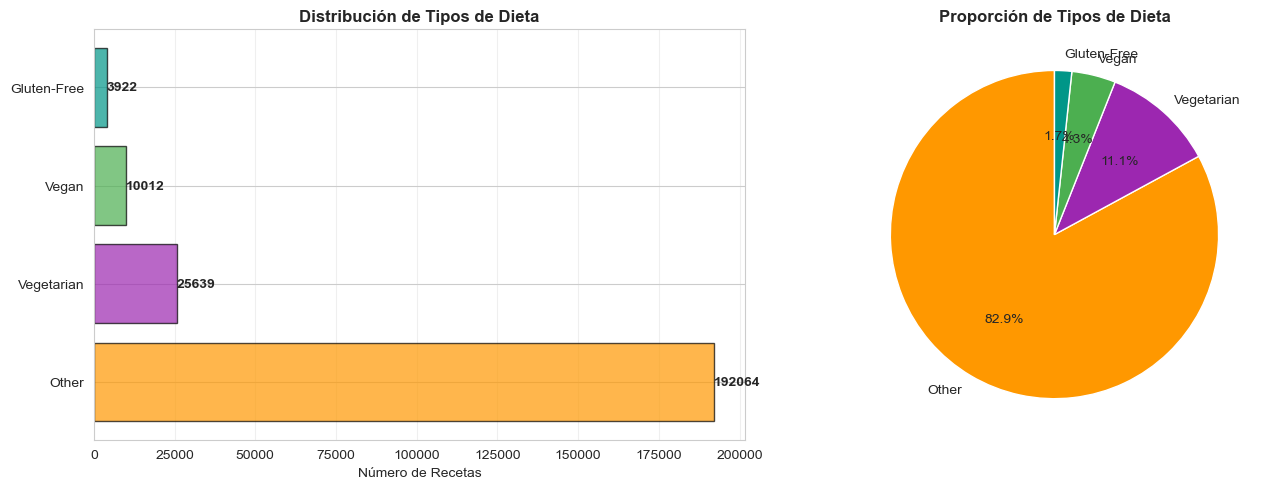

In [17]:
# Visualización de tipos de dieta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diet_counts = df['diet_type'].value_counts()
colors_diet = ['#FF9800', '#9C27B0', '#4CAF50', '#009688', '#2196F3', '#F44336']

# Gráfico de barras
axes[0].barh(diet_counts.index, diet_counts.values, color=colors_diet[:len(diet_counts)], edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Tipos de Dieta', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Número de Recetas')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(diet_counts.values):
    axes[0].text(v + 50, i, str(v), va='center', fontweight='bold')

# Gráfico de pastel
axes[1].pie(diet_counts.values, labels=diet_counts.index, colors=colors_diet[:len(diet_counts)], autopct='%1.1f%%',
           startangle=90)
axes[1].set_title('Proporción de Tipos de Dieta', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../data/diet_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


🔀 Análisis Cruzado: Nutri-Score × Tipo de Dieta
nutriscore      A     B     C     D       E
diet_type                                  
Gluten-Free   146   200   203   195    3178
Other        5110  6121  7109  8046  165678
Vegan         389   376   489   487    8271
Vegetarian    689   820  1091  1226   21813


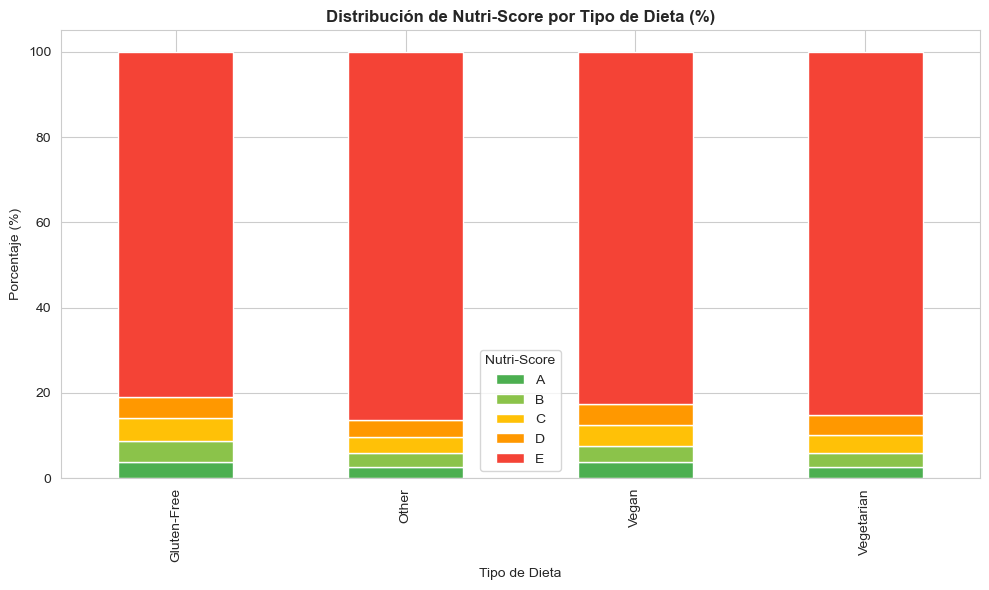

In [18]:
# Análisis cruzado: Nutri-Score vs Tipo de Dieta
print("\n🔀 Análisis Cruzado: Nutri-Score × Tipo de Dieta")
crosstab = pd.crosstab(df['diet_type'], df['nutriscore'])
print(crosstab)

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
crosstab_pct.plot(kind='bar', stacked=True, ax=ax, color=['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336'])
ax.set_title('Distribución de Nutri-Score por Tipo de Dieta (%)', fontweight='bold', fontsize=12)
ax.set_xlabel('Tipo de Dieta')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Nutri-Score')
plt.tight_layout()
plt.savefig('../data/diet_nutriscore_crosstab.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 6. Análisis de Ingredientes

### Importancia para NLP/RAG
Los ingredientes son datos no estructurados que analizaremos con TF-IDF y sugeriremos substituciones saludables.

In [19]:
# Extracción de número de ingredientes
def extract_n_ingredients(ingredients_str):
    try:
        ingredients_list = ast.literal_eval(ingredients_str)
        return len(ingredients_list)
    except:
        return np.nan

df['n_ingredients'] = df['ingredients'].progress_apply(extract_n_ingredients)

print("✓ Número de ingredientes extraído")
print(f"\nEstadísticas:")
print(df['n_ingredients'].describe().round(2))

100%|██████████| 231637/231637 [00:15<00:00, 14743.65it/s]

✓ Número de ingredientes extraído

Estadísticas:
count    231637.00
mean          9.05
std           3.73
min           1.00
25%           6.00
50%           9.00
75%          11.00
max          43.00
Name: n_ingredients, dtype: float64


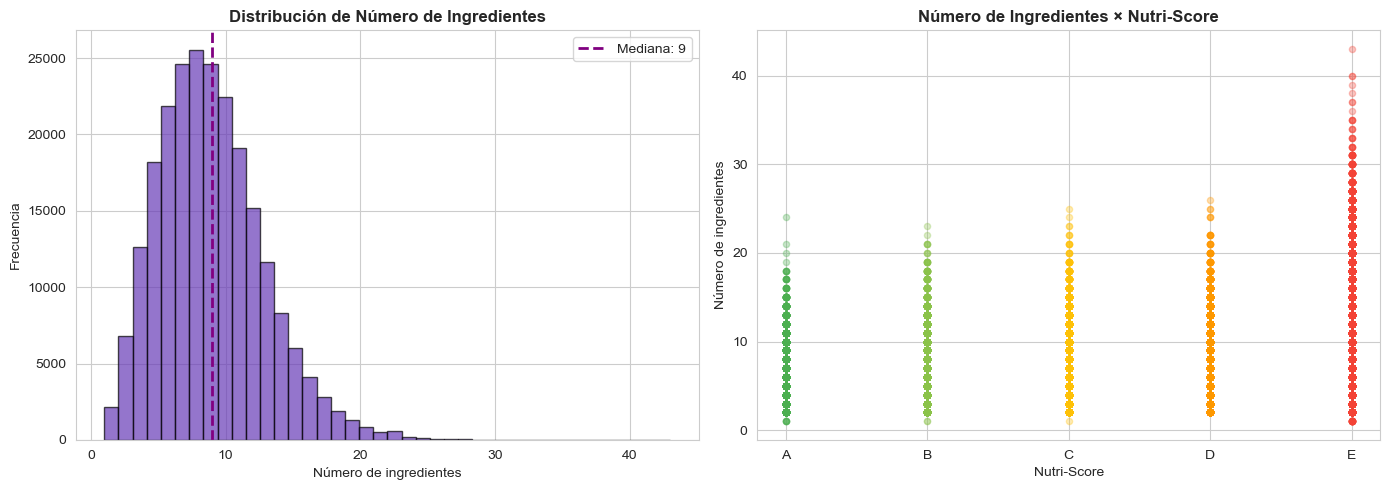

In [20]:
# Visualización de ingredientes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución
axes[0].hist(df['n_ingredients'].dropna(), bins=40, color='#673AB7', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Número de Ingredientes', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Número de ingredientes')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['n_ingredients'].median(), color='purple', linestyle='--', linewidth=2, label=f"Mediana: {df['n_ingredients'].median():.0f}")
axes[0].legend()

# Relación: ingredientes vs nutriscore
for score, color in zip(['A', 'B', 'C', 'D', 'E'], ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']):
    subset = df[df['nutriscore'] == score]
    axes[1].scatter([score]*len(subset), subset['n_ingredients'], alpha=0.3, color=color, s=20)
axes[1].set_title('Número de Ingredientes × Nutri-Score', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Nutri-Score')
axes[1].set_ylabel('Número de ingredientes')

plt.tight_layout()
plt.savefig('../data/ingredients_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 7. Resumen de Dataset Preprocesado

### Estadísticas Finales

In [21]:
print("\n" + "="*80)
print("📊 RESUMEN FINAL DE DATASET PREPROCESADO")
print("="*80)

print(f"\n✓ Total de recetas analizadas: {len(df):,}")
print(f"\n🏷️  TARGETS CREADOS:")
print(f"   - Nutri-Score (A-E): {df['nutriscore'].nunique()} clases")
print(f"     • A: {(df['nutriscore']=='A').sum():,} recetas")
print(f"     • B: {(df['nutriscore']=='B').sum():,} recetas")
print(f"     • C: {(df['nutriscore']=='C').sum():,} recetas")
print(f"     • D: {(df['nutriscore']=='D').sum():,} recetas")
print(f"     • E: {(df['nutriscore']=='E').sum():,} recetas")

print(f"\n   - Dificultad: {df['difficulty'].nunique()} clases")
print(f"     • Easy: {(df['difficulty']=='Easy').sum():,} recetas")
print(f"     • Medium: {(df['difficulty']=='Medium').sum():,} recetas")
print(f"     • Hard: {(df['difficulty']=='Hard').sum():,} recetas")

print(f"\n   - Tipo de Dieta: {df['diet_type'].nunique()} clases")
for diet in df['diet_type'].unique():
    print(f"     • {diet}: {(df['diet_type']==diet).sum():,} recetas")

print(f"\n📈 CARACTERÍSTICAS NUMÉRICAS:")
print(f"   - Calorías:              Media={df['calories'].mean():.0f}, Mediana={df['calories'].median():.0f}")
print(f"   - Azúcar (g):            Media={df['sugar'].mean():.2f}, Mediana={df['sugar'].median():.2f}")
print(f"   - Grasas Saturadas (g):  Media={df['sat_fat'].mean():.2f}, Mediana={df['sat_fat'].median():.2f}")
print(f"   - Proteína (g):          Media={df['protein'].mean():.2f}, Mediana={df['protein'].median():.2f}")
print(f"   - Pasos:                 Media={df['n_steps'].mean():.1f}, Mediana={df['n_steps'].median():.0f}")
print(f"   - Minutos:               Media={df['minutes'].mean():.1f}, Mediana={df['minutes'].median():.0f}")
print(f"   - Ingredientes:          Media={df['n_ingredients'].mean():.1f}, Mediana={df['n_ingredients'].median():.0f}")

print(f"\n✅ Dataset listo para preprocesamiento y modelado NLP")
print("="*80)


📊 RESUMEN FINAL DE DATASET PREPROCESADO

✓ Total de recetas analizadas: 231,637

🏷️  TARGETS CREADOS:
   - Nutri-Score (A-E): 5 clases
     • A: 6,334 recetas
     • B: 7,517 recetas
     • C: 8,892 recetas
     • D: 9,954 recetas
     • E: 198,940 recetas

   - Dificultad: 3 clases
     • Easy: 36,849 recetas
     • Medium: 80,712 recetas
     • Hard: 114,076 recetas

   - Tipo de Dieta: 4 clases
     • Vegetarian: 25,639 recetas
     • Other: 192,064 recetas
     • Vegan: 10,012 recetas
     • Gluten-Free: 3,922 recetas

📈 CARACTERÍSTICAS NUMÉRICAS:
   - Calorías:              Media=474, Mediana=313
   - Azúcar (g):            Media=30.15, Mediana=14.00
   - Grasas Saturadas (g):  Media=84.30, Mediana=25.00
   - Proteína (g):          Media=34.68, Mediana=18.00
   - Pasos:                 Media=9.8, Mediana=9
   - Minutos:               Media=9398.5, Mediana=40
   - Ingredientes:          Media=9.1, Mediana=9

✅ Dataset listo para preprocesamiento y modelado NLP


In [22]:
# Guardado del dataset con targets generados
output_cols = df.columns.tolist()
df_output = df[['id', 'name', 'minutes', 'n_steps', 'n_ingredients', 'calories', 'sugar', 'sat_fat', 
                'protein', 'sodium', 'fiber', 'nutriscore', 'difficulty', 'diet_type', 'ingredients', 'steps', 'tags']]
df_output.to_csv('../data/recipes_with_targets.csv', index=False)

print("✓ Dataset con targets guardado en: ../data/recipes_with_targets.csv")

✓ Dataset con targets guardado en: ../data/recipes_with_targets.csv


---
## 8. Insights y Conclusiones

### Hallazgos principales:
1. **Distribución de Nutri-Score**: Mayoría en C-D (recetas moderadamente saludables)
2. **Correlación nutrientes**: Calorías y proteína altamente correlacionadas
3. **Dificultad**: Predominan recetas de dificultad Media a Hard
4. **Tipos de dieta**: "Other" domina (68%), oportunidad para atraer públicos especializados
5. **Ingredientes**: Promedio ~10 ingredientes, con varianza significativa

### Próximos pasos (Notebooks posteriores):
1. **NLP Pipeline**: Lematización, POS tagging, extracción de verbos de acción
2. **Representación**: TF-IDF + SVD (LSA)
3. **Modelado**: Naive Bayes + LSTM
4. **RAG**: Recomendador de ingredientes saludables

In [23]:
import pandas as pd
import ast

df = pd.read_csv("../data/RAW_recipes.csv")
df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


In [24]:
import spacy
import en_core_web_sm # Importamos el modelo directamente como un paquete

# En lugar de spacy.load("en_core_web_sm"), haz esto:
nlp = en_core_web_sm.load()

# Ahora ya puedes seguir con los niveles de NLP de tus apuntes:
# Tokenización, Morfología (POS, Lema) y Sintaxis (Parsing) [cite: 57, 58, 62]

def preprocess_nlp(text):
    # Tokenización y normalización (Morfología) [cite: 71, 79, 81]
    doc = nlp(str(text).lower())
    
    # Filtramos Stopwords y puntuación [cite: 79, 139]
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return " ".join(tokens)

# Aplicamos a una pequeña muestra para probar
df['cleaned_description'] = df['description'].head(20000).apply(preprocess_nlp)
print(df['cleaned_description'].head())

0    autumn favorite time year cook recipe \r\n pre...
1    recipe call crust prebake bit add ingredient f...
2    modify version mom chili hit 2004 christmas pa...
3    super easy great tasting ahead dish look like ...
4    dh amish mother raise recipe prefer store buy ...
Name: cleaned_description, dtype: object


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Configuramos el vectorizador
# max_features=2000 limita el vocabulario a las 2000 palabras más importantes
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

# 2. Transformamos nuestras descripciones limpias en una matriz numérica
# Usamos solo la muestra que limpiaste antes
tfidf_matrix = tfidf.fit_transform(df['cleaned_description'].dropna())

print(f"Matriz creada: {tfidf_matrix.shape}") # (Documentos, Vocabulario)

Matriz creada: (20000, 2000)
